# Pipeline Walkthrough

End-to-end satellite image segmentation using the thesis-selected pipeline:

**EPSF pre-filter → H-image → Vincent-Soille watershed → RM3 region merging**

This notebook demonstrates each stage with visualisations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from watershed_seg import Pipeline, evaluate
from watershed_seg.filters import epsf
from watershed_seg.watershed_input import h_image
from watershed_seg.watershed import vincent_soille
from watershed_seg.merging import rm3
from watershed_seg.evaluation import simplified_image

# Synthetic 4-quadrant image (replace with np.load('path/to/image.npy') for real data)
rng = np.random.default_rng(42)
img = np.zeros((64, 64, 3), dtype=np.float64)
img[:32, :32] = rng.uniform(200, 220, (32, 32, 3))  # bright top-left
img[:32, 32:] = rng.uniform(50,  70,  (32, 32, 3))  # dark top-right
img[32:, :32] = rng.uniform(100, 120, (32, 32, 3))  # mid bottom-left
img[32:, 32:] = rng.uniform(150, 170, (32, 32, 3))  # mid bottom-right
print(f'Image shape: {img.shape}, value range: [{img.min():.0f}, {img.max():.0f}]')

Matplotlib is building the font cache; this may take a moment.


Image shape: (64, 64, 3), value range: [50, 220]


## Stage 1: EPSF Pre-filter

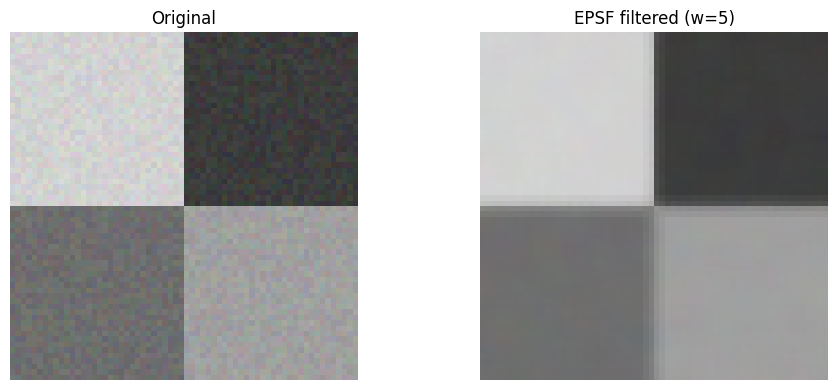

Std dev: before=56.27, after=54.75


In [2]:
filtered = epsf(img, w=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.astype(np.uint8))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(filtered.astype(np.uint8))
axes[1].set_title('EPSF filtered (w=5)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Std dev: before={img.std():.2f}, after={filtered.std():.2f}')

## Stage 2: H-image

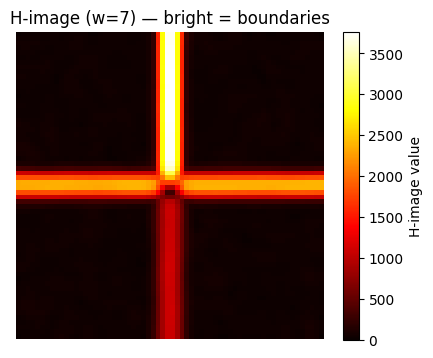

H-image range: [0.00, 3764.94]


In [3]:
gradient = h_image(filtered, w=7)

plt.figure(figsize=(5, 4))
plt.imshow(gradient, cmap='hot')
plt.colorbar(label='H-image value')
plt.title('H-image (w=7) — bright = boundaries')
plt.axis('off')
plt.show()
print(f'H-image range: [{gradient.min():.2f}, {gradient.max():.2f}]')

## Stage 3: Vincent-Soille Watershed

Watershed segments: 173


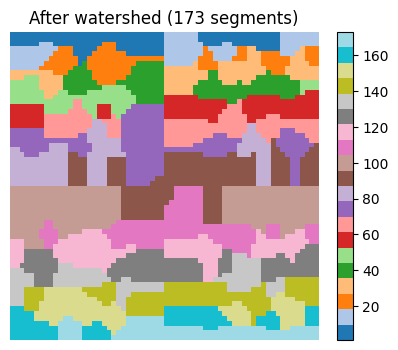

In [4]:
ws_labels = vincent_soille(gradient)
n_ws = int(ws_labels.max())
print(f'Watershed segments: {n_ws}')

plt.figure(figsize=(5, 4))
plt.imshow(ws_labels, cmap='tab20')
plt.title(f'After watershed ({n_ws} segments)')
plt.axis('off')
plt.colorbar()
plt.show()

## Stage 4: RM3 Region Merging (Proposed)

Final segments: 5  (reduced from 173)


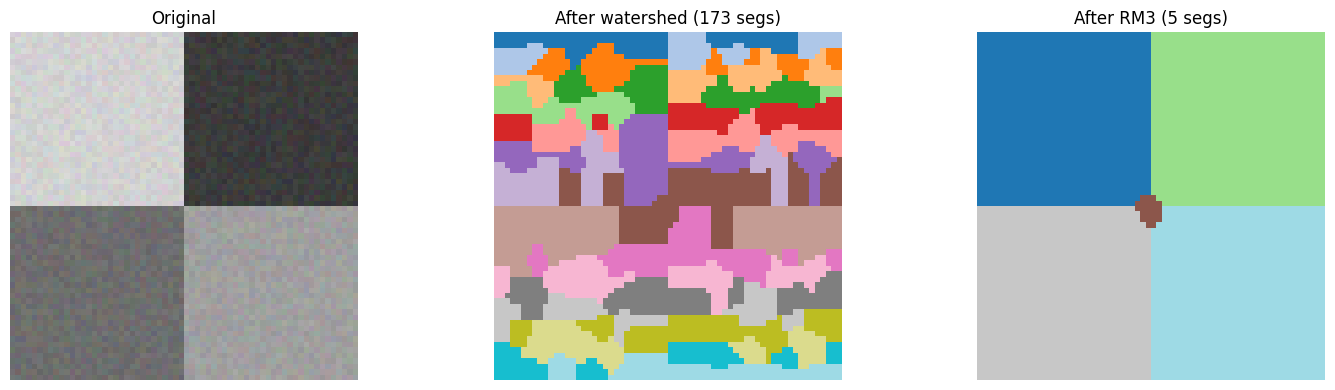

In [5]:
final_labels = rm3(ws_labels, img, size_threshold=20, cost_threshold=500)
n_final = int(final_labels.max())
print(f'Final segments: {n_final}  (reduced from {n_ws})')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img.astype(np.uint8))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(ws_labels, cmap='tab20')
axes[1].set_title(f'After watershed ({n_ws} segs)')
axes[1].axis('off')
axes[2].imshow(final_labels, cmap='tab20')
axes[2].set_title(f'After RM3 ({n_final} segs)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Simplified (region-mean) image

PSNR: 31.43 dB


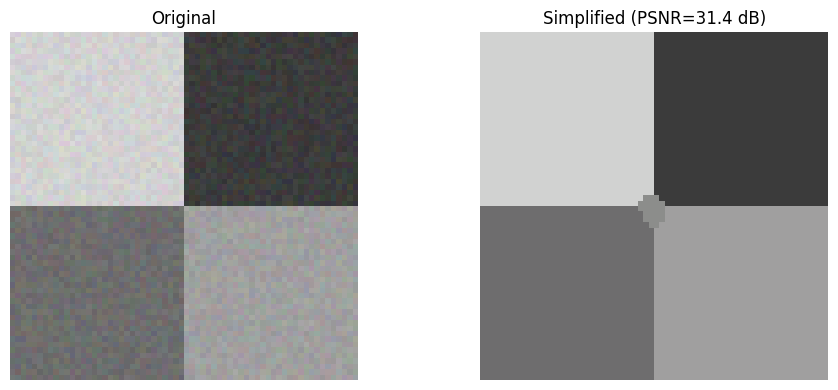

In [6]:
from watershed_seg.evaluation import psnr
simp = simplified_image(final_labels, img)
score = psnr(img, simp)
print(f'PSNR: {score:.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img.astype(np.uint8))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(simp.astype(np.uint8))
axes[1].set_title(f'Simplified (PSNR={score:.1f} dB)')
axes[1].axis('off')
plt.tight_layout()
plt.show()